# Importing the dependencies

In [1]:
import pandas as pd
import numpy as np
import time
import json

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
import joblib

print(f"TensorFlow version: {tf.__version__}")
print("All dependencies loaded.")

TensorFlow version: 2.21.0
All dependencies loaded.


# Loading and Cleaning the data

In [2]:
df = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/combined_train_dataset.csv')
df = df.dropna()
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")

Dataset shape: (21740, 127)
Class distribution:
label
S    1400
D    1400
E    1400
F    1400
G    1400
I    1400
K    1400
P    1400
Q    1400
R    1340
A     600
X     600
W     600
V     600
U     600
T     600
N     600
O     600
B     600
M     600
L     600
C     600
Z     600
Name: count, dtype: int64


# Data augmentation

In [3]:
np.random.seed(42)
print("Random seed set to 42 — results will be reproducible")

Random seed set to 42 — results will be reproducible


In [4]:
def augment_dataset(df, n_augments, noise_std=0.01):
    feature_cols = [c for c in df.columns if c != 'label']
    augmented_rows = []

    for _, row in df.iterrows():
        features = row[feature_cols].values.astype(float)
        label = row['label']
        for _ in range(n_augments):
            noise = np.random.normal(0, noise_std, features.shape)
            augmented = features + noise
            augmented_rows.append(list(augmented) + [label])

    aug_df = pd.DataFrame(augmented_rows, columns=df.columns)
    return pd.concat([df, aug_df], ignore_index=True)


# Load merged dataset
df = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/combined_train_dataset.csv')
df = df.dropna()
print(f"Before augmentation: {df.shape}")

# Split by group
non_targeted = ['A','B','C','L','M','N','O','T','U','V','W','X','Z']
targeted     = ['D','E','F','G','I','K','P','Q','R','S']

df_non = df[df['label'].isin(non_targeted)]
df_tgt = df[df['label'].isin(targeted)]

# Non-targeted: 600 × 5 = 3000 each
# Targeted: ~1400 × 2 = 2800 each
# Both land at roughly 3000 — balanced
df_non_aug = augment_dataset(df_non, n_augments=4)
df_tgt_aug = augment_dataset(df_tgt, n_augments=1)

df_augmented = pd.concat([df_non_aug, df_tgt_aug], ignore_index=True)

print(f"After augmentation:  {df_augmented.shape}")

Before augmentation: (21740, 127)
After augmentation:  (66880, 127)


=== Samples per sign after augmentation ===
label
A    3000
B    3000
C    3000
D    2800
E    2800
F    2800
G    2800
I    2800
K    2800
L    3000
M    3000
N    3000
O    3000
P    2800
Q    2800
R    2680
S    2800
T    3000
U    3000
V    3000
W    3000
X    3000
Z    3000
Name: count, dtype: int64

Min: 2680  |  Max: 3000
Ratio (max/min): 1.12x

NaN values: 0

Feature min: -0.4377
Feature max: 0.3055
Values outside -3 to 3 range: 0


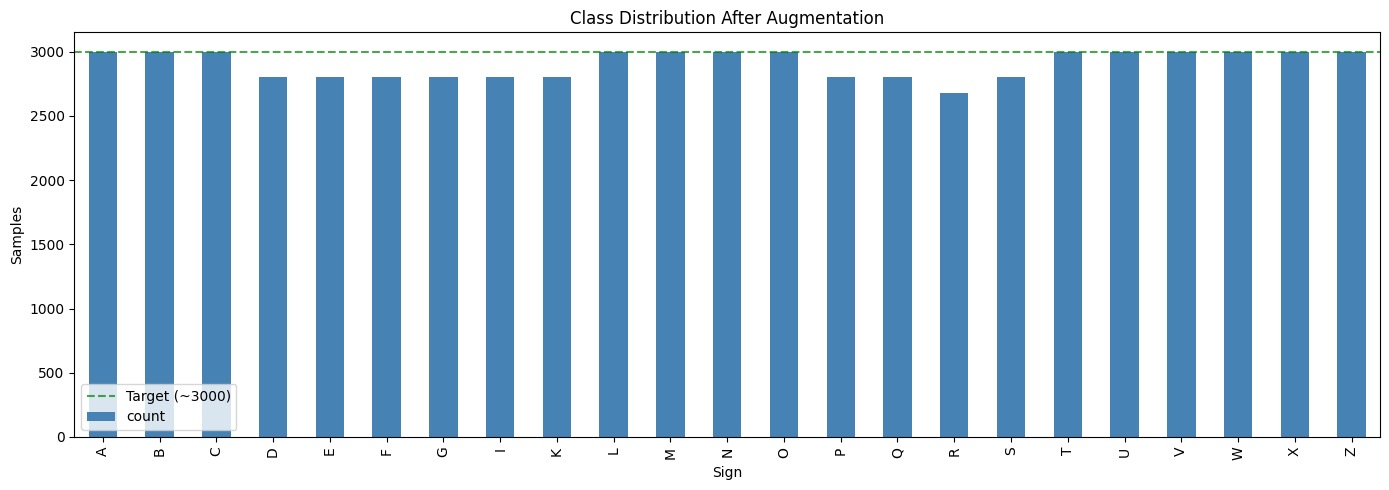


✓ Ready for train/test split


In [5]:
counts = df_augmented['label'].value_counts().sort_index()

print("=== Samples per sign after augmentation ===")
print(counts)
print(f"\nMin: {counts.min()}  |  Max: {counts.max()}")
print(f"Ratio (max/min): {counts.max()/counts.min():.2f}x")

# Any NaN introduced by augmentation
nulls = df_augmented.isnull().sum().sum()
print(f"\nNaN values: {nulls}")

# Feature range check — should still be roughly -1.5 to 1.5
feature_cols = [c for c in df_augmented.columns if c != 'label']
X = df_augmented[feature_cols]
print(f"\nFeature min: {X.min().min():.4f}")
print(f"Feature max: {X.max().max():.4f}")
print(f"Values outside -3 to 3 range: {(X.abs() > 3).sum().sum()}")

# Visual
import matplotlib.pyplot as plt

counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
plt.axhline(y=3000, color='green', linestyle='--',
            label='Target (~3000)', alpha=0.7)
plt.title('Class Distribution After Augmentation')
plt.xlabel('Sign')
plt.ylabel('Samples')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/class_distribution_augmented.png', dpi=150)
plt.show()

print("\n✓ Ready for train/test split")

# Splitting features and labels

In [6]:
X = df_augmented.drop('label', axis=1).values
y = df_augmented['label'].values

# Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 53504 | Test: 13376


# Training Random Forest

In [8]:
print("Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_time = round(time.time() - start, 2)
rf_preds = rf.predict(X_test)
print(f"Train time: {rf_time}s")
print(classification_report(y_test, rf_preds))

Training Random Forest...
Train time: 40.15s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           S       1.00      1.00   

# Training Extra Trees

In [9]:
print("Training Extra Trees...")
start = time.time()
et = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
et.fit(X_train, y_train)
et_time = round(time.time() - start, 2)
et_preds = et.predict(X_test)
print(f"Train time: {et_time}s")
print(classification_report(y_test, et_preds))

Training Extra Trees...
Train time: 4.06s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           S       1.00      1.00      

# Training SVC

In [10]:
print("Training SVM (RBF)... this will take a few minutes")
start = time.time()
svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train, y_train)
svm_time = round(time.time() - start, 2)
svm_preds = svm.predict(X_test)
print(f"Train time: {svm_time}s")
print(classification_report(y_test, svm_preds))

Training SVM (RBF)... this will take a few minutes
Train time: 13.15s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           

# Training MLP

In [11]:
print("Training MLP...")
start = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train, y_train)
mlp_time = round(time.time() - start, 2)
mlp_preds = mlp.predict(X_test)
print(f"Train time: {mlp_time}s")
print(classification_report(y_test, mlp_preds))

Training MLP...
Train time: 20.6s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           S       1.00      1.00      1.00    

# Training KNN

In [12]:
print("Training KNN k=5...")
start = time.time()
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
knn5_time = round(time.time() - start, 2)
knn5_preds = knn5.predict(X_test)
print(f"Train time: {knn5_time}s")
print(classification_report(y_test, knn5_preds))

print("\nTraining KNN k=3...")
start = time.time()
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
knn3_time = round(time.time() - start, 2)
knn3_preds = knn3.predict(X_test)
print(f"Train time: {knn3_time}s")
print(classification_report(y_test, knn3_preds))

Training KNN k=5...
Train time: 0.08s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       560
           E       1.00      1.00      1.00       560
           F       1.00      1.00      1.00       560
           G       1.00      1.00      1.00       560
           I       1.00      1.00      1.00       560
           K       1.00      1.00      1.00       560
           L       1.00      1.00      1.00       600
           M       1.00      1.00      1.00       600
           N       1.00      1.00      1.00       600
           O       1.00      1.00      1.00       600
           P       1.00      1.00      1.00       560
           Q       1.00      1.00      1.00       560
           R       1.00      1.00      1.00       536
           S       1.00      1.00      1.00

# Training Keras MLP

In [13]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
num_classes  = len(le.classes_)

keras_model = keras.Sequential([
    keras.layers.Input(shape=(126,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

keras_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

keras_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\nTraining Keras MLP...")
start = time.time()
history = keras_model.fit(
    X_train, y_train_enc,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
keras_time = round(time.time() - start, 2)
print(f"Train time: {keras_time}s")

keras_proba    = keras_model.predict(X_test)
keras_preds_enc = np.argmax(keras_proba, axis=1)
keras_preds    = le.inverse_transform(keras_preds_enc)

print("\n=== Keras MLP ===")
print(classification_report(y_test, keras_preds))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        32,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,159 (293.59 KB)

 Trainable params: 75,159 (293.59 KB)

 Non-trainable params: 0 (0.00 B)


Training Keras MLP...
Epoch 1/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step - accuracy: 0.9175 - loss: 0.2802 - val_accuracy: 0.9978 - val_loss: 0.0117
Epoch 2/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.9939 - loss: 0.0220 - val_accuracy: 0.9966 - val_loss: 0.0081
Epoch 3/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.9994 - val_loss: 0.0021
Epoch 4/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.9971 - loss: 0.0100 - val_accuracy: 0.9996 - val_loss: 8.6537e-04
Epoch 5/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - accuracy: 0.9978 - loss: 0.0069 - val_accuracy: 0.9989 - val_loss: 0.0032
Epoch 6/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1s 794us/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9998 - val_loss: 7.4358e-04
Epoch 7/100
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.9984 - loss: 0.0054 - val_accuracy: 0.9996 - val_loss: 8.7448e-04
Epoch 8/100
1505/1505 ━━━━━━━━━━━━

# Comparison table of the alogorithms

In [15]:
all_results = {
    'Random Forest': (rf,   rf_preds,    rf_time),
    'MLP (sklearn)': (mlp,  mlp_preds,   mlp_time),
    'Extra Trees':   (et,   et_preds,    et_time),
    'SVM (RBF)':     (svm,  svm_preds,   svm_time),
    'KNN (k=5)':     (knn5, knn5_preds,  knn5_time),
    'KNN (k=3)':     (knn3, knn3_preds,  knn3_time),
    'Keras MLP':     (None, keras_preds, keras_time),
}

rows = []
for name, (model, preds, t) in all_results.items():
    r = classification_report(y_test, preds, output_dict=True)
    rows.append({
        'Algorithm':      name,
        'Accuracy':       round(r['accuracy'], 4),
        'Weighted F1':    round(r['weighted avg']['f1-score'], 4),
        'Train Time (s)': t,
    })

summary_df = pd.DataFrame(rows).sort_values(
    'Weighted F1', ascending=False
).reset_index(drop=True)

print("=== Algorithm Comparison ===")
print(summary_df.to_string(index=False))
summary_df.to_csv('/Users/dwibon/Desktop/ISL-FingerSpell/assets/algorithms_comparison.csv', index=False)

=== Algorithm Comparison ===
    Algorithm  Accuracy  Weighted F1  Train Time (s)
    KNN (k=5)    1.0000       1.0000            0.08
    KNN (k=3)    1.0000       1.0000            0.07
MLP (sklearn)    0.9999       0.9999           20.60
  Extra Trees    0.9999       0.9999            4.06
    Keras MLP    0.9998       0.9998           29.07
Random Forest    0.9997       0.9997           40.15
    SVM (RBF)    0.9997       0.9997           13.15


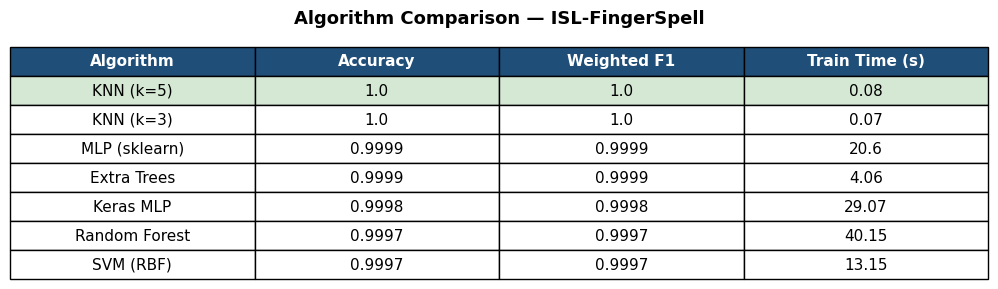

Saved.


In [16]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Header row styling
for j in range(len(summary_df.columns)):
    table[(0, j)].set_facecolor('#1F4E79')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Highlight best row (index 0 since sorted by Weighted F1)
for j in range(len(summary_df.columns)):
    table[(1, j)].set_facecolor('#d5e8d4')

plt.title('Algorithm Comparison — ISL-FingerSpell', 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/algorithms_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

# Testing on held out test data

In [17]:
df_holdout = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/held_out_dataset.csv')
df_holdout = df_holdout.dropna()
X_holdout  = df_holdout.drop('label', axis=1).values
y_holdout  = df_holdout['label'].values

holdout_results = {}

# Sklearn models
sklearn_models = {
    'Random Forest': (rf,   rf.classes_),
    'MLP (sklearn)': (mlp,  mlp.classes_),
    'Extra Trees':   (et,   et.classes_),
    'SVM (RBF)':     (svm,  svm.classes_),
    'KNN (k=5)':     (knn5, knn5.classes_),
    'KNN (k=3)':     (knn3, knn3.classes_),
}

for name, (model, _) in sklearn_models.items():
    preds = model.predict(X_holdout)
    r = classification_report(y_holdout, preds, output_dict=True)
    holdout_results[name] = round(r['weighted avg']['f1-score'], 4)
    print(f"{name}: {holdout_results[name]}")

# Keras MLP
keras_holdout_proba = keras_model.predict(X_holdout)
keras_holdout_preds = le.inverse_transform(
    np.argmax(keras_holdout_proba, axis=1))
r = classification_report(y_holdout, keras_holdout_preds, output_dict=True)
holdout_results['Keras MLP'] = round(r['weighted avg']['f1-score'], 4)
print(f"Keras MLP: {holdout_results['Keras MLP']}")

# Summary
holdout_df = pd.DataFrame([
    {'Algorithm': k, 'Held-Out Weighted F1': v}
    for k, v in holdout_results.items()
]).sort_values('Held-Out Weighted F1', ascending=False).reset_index(drop=True)

print("\n=== Held-Out Comparison ===")
print(holdout_df.to_string(index=False))
holdout_df.to_csv('/Users/dwibon/Desktop/ISL-FingerSpell/assets/holdout_comparison.csv', index=False)

Random Forest: 0.9673
MLP (sklearn): 0.9405
Extra Trees: 0.9652
SVM (RBF): 0.9619
KNN (k=5): 0.9007


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


KNN (k=3): 0.9026
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Keras MLP: 0.9652

=== Held-Out Comparison ===
    Algorithm  Held-Out Weighted F1
Random Forest                0.9673
  Extra Trees                0.9652
    Keras MLP                0.9652
    SVM (RBF)                0.9619
MLP (sklearn)                0.9405
    KNN (k=3)                0.9026
    KNN (k=5)                0.9007


In [18]:
df_holdout = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/held_out_dataset.csv')
df_holdout = df_holdout.dropna()

X_holdout = df_holdout.drop('label', axis=1).values
y_holdout = df_holdout['label'].values

holdout_preds = rf.predict(X_holdout)
print("=== Held-Out User (cross-user generalisation) ===")
print(classification_report(y_holdout, holdout_preds))

=== Held-Out User (cross-user generalisation) ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        50
           B       1.00      1.00      1.00        50
           C       0.98      1.00      0.99        50
           D       1.00      1.00      1.00        50
           E       0.94      1.00      0.97        50
           F       1.00      1.00      1.00        50
           G       1.00      1.00      1.00        50
           I       1.00      1.00      1.00        50
           K       1.00      1.00      1.00        50
           L       1.00      1.00      1.00        50
           M       1.00      1.00      1.00        50
           N       0.98      1.00      0.99        50
           O       1.00      1.00      1.00        50
           P       1.00      1.00      1.00        50
           Q       1.00      0.72      0.84        50
           R       0.89      1.00      0.94        50
           S       1.00      0.

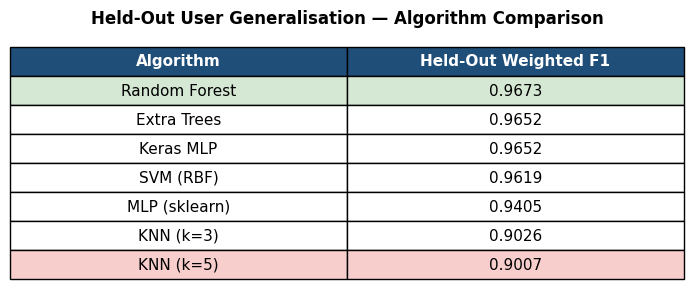

Saved.


In [19]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.axis('off')

table = ax.table(
    cellText=holdout_df.values,
    colLabels=holdout_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(holdout_df.columns)):
    table[(0, j)].set_facecolor('#1F4E79')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Highlight best model (row 1)
for j in range(len(holdout_df.columns)):
    table[(1, j)].set_facecolor('#d5e8d4')

# Red highlight for worst model (last row)
for j in range(len(holdout_df.columns)):
    table[(len(holdout_df), j)].set_facecolor('#f8cecc')

plt.title('Held-Out User Generalisation — Algorithm Comparison',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/holdout_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

# confusion Matrix

On Train/Test Data

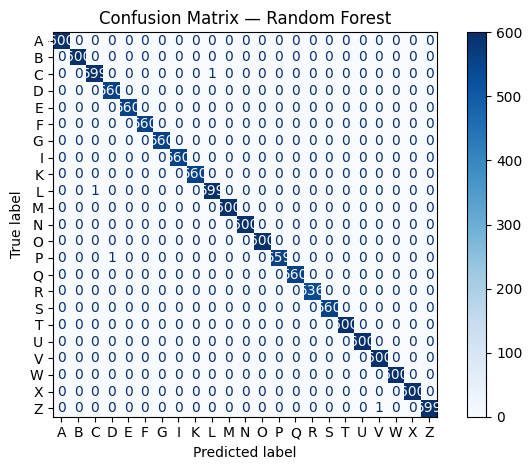

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=rf.classes_,
    cmap='Blues'
)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/confusion_matrix.png', dpi=150)
plt.show()

On Held Out Data

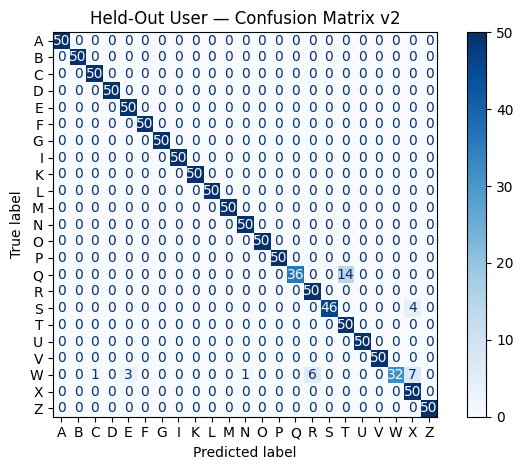

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    holdout_preds,
    display_labels=rf.classes_,
    cmap='Blues'
)
plt.title("Held-Out User — Confusion Matrix v2")
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/confusion_matrix_holdout.png', dpi=150)
plt.show()

# Saving the better model

In [18]:
joblib.dump(rf, '/Users/dwibon/Desktop/ISL-FingerSpell/models/isl_model.pkl')
joblib.dump(rf.classes_, '/Users/dwibon/Desktop/ISL-FingerSpell/models/classes.pkl')
print("Model saved.")

Model saved.
